CLAHE *(Contrast Limited Adaptive Histogram Equalization)* is an image processing technique in OpenCV used to enhance the contrast of images, especially in regions with low contrast. It is an improved version of histogram equalization and is particularly useful for medical images, satellite images, or low-light conditions.

#### How CLAHE Works:
1. The image is divided into small blocks called tiles (e.g., 8×8).

2. Histogram equalization is applied to each tile.

3. To avoid abrupt boundaries between tiles, bilinear interpolation is used to combine neighboring tiles.

4. Contrast limiting is applied to prevent over-amplification of noise by clipping the histogram at a predefined threshold.

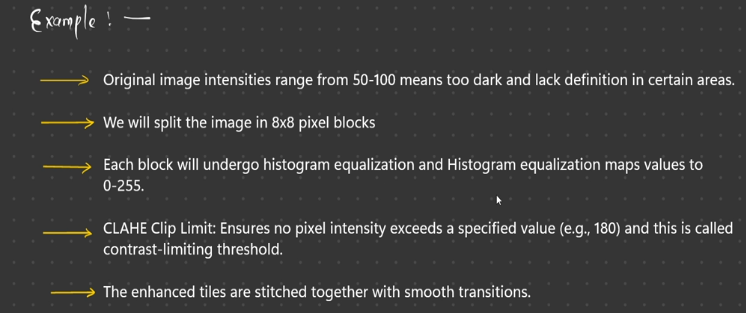



In [10]:
import cv2
import matplotlib.pyplot as plt

In [21]:
image = cv2.imread("asserts/giraffe-Kenya.png")

Text(0.5, 1.0, 'Clahe Equalised Image')

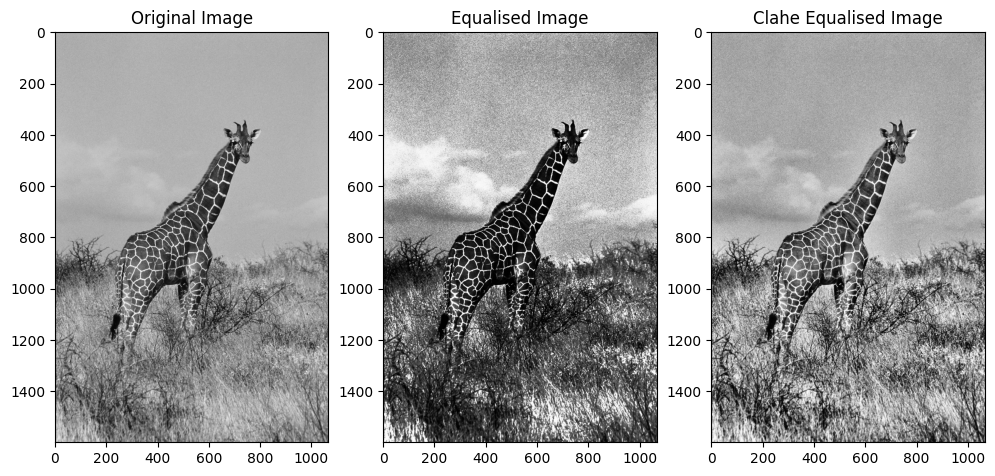

In [22]:
image_grey = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

equalised_image = cv2.equalizeHist(image_grey)

clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))

clahe_equalised_image = clahe.apply(image_grey)

plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
plt.imshow(image_grey,cmap='grey')
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(equalised_image,cmap='grey')
plt.title("Equalised Image")

plt.subplot(1,3,3)
plt.imshow(clahe_equalised_image,cmap='grey')
plt.title("Clahe Equalised Image")

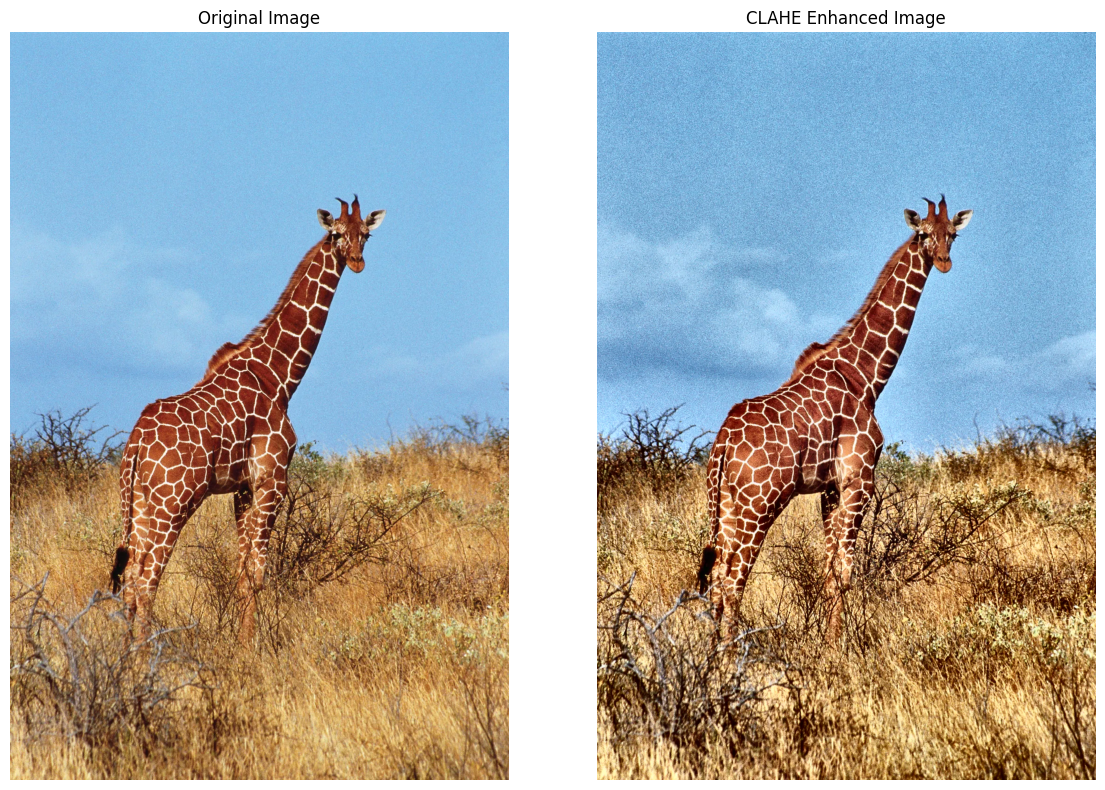

In [24]:
yuv_image = cv2.cvtColor(image,cv2.COLOR_BGR2YUV)


# Split the channels
y, u, v = cv2.split(yuv_image)

# Apply CLAHE to the Y channel
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
y_clahe = clahe.apply(y)

# Merge the channels back
yuv_clahe = cv2.merge((y_clahe, u, v))


# Convert back to BGR then RGB
bgr_clahe = cv2.cvtColor(yuv_clahe, cv2.COLOR_YUV2BGR)
rgb_clahe = cv2.cvtColor(bgr_clahe, cv2.COLOR_BGR2RGB)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_clahe)
plt.title("CLAHE Enhanced Image")
plt.axis('off')

plt.tight_layout()
plt.show()
